In [4]:
import sys
sys.path.insert(0, '..')

# Le problème max-cut : s1s5 + s2s5 + s3s5 + s4s5
# 5 noeuds, s5 (index 4) est connecté à tous les autres
ising_problem = {
    'linear':    {0: 0, 1: 0, 2: 0, 3: 0, 4: 0},
    'quadratic': {(0,4): 1, (1,4): 1, (2,4): 1, (3,4): 1}
}

print(ising_problem)

{'linear': {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}, 'quadratic': {(0, 4): 1, (1, 4): 1, (2, 4): 1, (3, 4): 1}}


In [5]:
# Identifier la solution optimale par brute force
# 5 qubits → 2^5 = 32 combinaisons
best_value = float('inf')
best_solutions = []

for mask in range(1 << 5):
    # convertir les bits en spins -1/+1
    spins = [1 if (mask >> i) & 1 else -1 for i in range(5)]
    
    # calculer le coût : s1s5 + s2s5 + s3s5 + s4s5
    cost = (spins[0]*spins[4] + spins[1]*spins[4] + 
            spins[2]*spins[4] + spins[3]*spins[4])
    
    if cost < best_value:
        best_value = cost
        best_solutions = [spins]
    elif cost == best_value:
        best_solutions.append(spins)

print(f"Valeur optimale : {best_value}")
print(f"Nombre de solutions optimales : {len(best_solutions)}")
for s in best_solutions:
    print(s)

Valeur optimale : -4
Nombre de solutions optimales : 2
[1, 1, 1, 1, -1]
[-1, -1, -1, -1, 1]


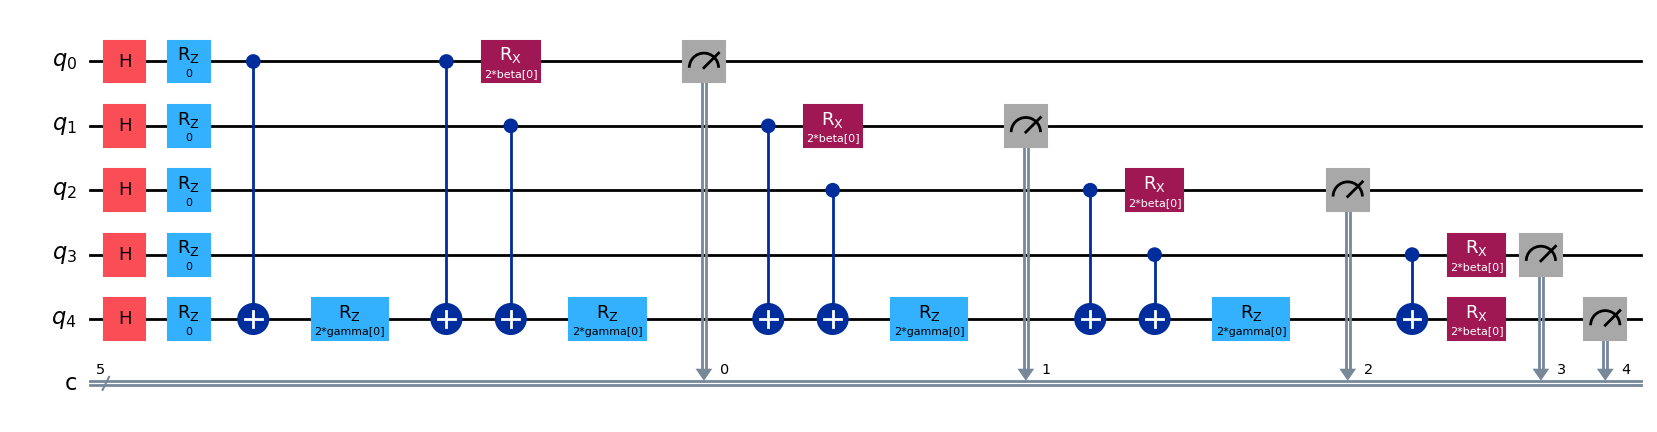

In [6]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from solver.quantum_solver.qaoa_solver.qaoa_mixers import add_ising_problem_ham, add_ising_mixer_ham

def build_qaoa_circuit(ising_problem):
    n = len(ising_problem['linear'])
    qc = QuantumCircuit(n, n)
    
    # Superposition uniforme
    for i in range(n):
        qc.h(i)
    
    # Problem Hamiltonian (Rz)
    qc, gammas = add_ising_problem_ham(qc, ising_problem, n)
    
    # Mixing Hamiltonian (Rx)
    qc, betas = add_ising_mixer_ham(qc, ising_problem, n)
    
    # Mesure
    qc.measure(range(n), range(n))
    
    return qc, gammas + betas

qc, params = build_qaoa_circuit(ising_problem)
qc.draw('mpl')